In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [32]:
!pwd

/content/drive/MyDrive/Road_flywheel_project


In [3]:
!pwd

/content/drive/MyDrive


In [4]:
!git clone https://github.com/aryanmathur1911/Road_flywheel_project.git

Cloning into 'Road_flywheel_project'...
remote: Enumerating objects: 43, done.
remote: Counting objects: 100% (43/43), done.
remote: Compressing objects: 100% (30/30), done.
remote: Total 43 (delta 13), reused 36 (delta 10), pack-reused 0 (from 0)
Receiving objects: 100% (43/43), 40.08 MiB | 20.50 MiB/s, done.
Resolving deltas: 100% (13/13), done.


In [7]:
!mkdir -p \
data/raw \
data/masks \
data/processed/train/Broken \
"data/processed/train/Not Broken" \
data/processed/val \
data/synthetic/images/Broken \
"data/synthetic/images/Not Broken" \
data/synthetic/labels \
models/checkpoints \
models/sam_weights

In [11]:
%cd /content/drive/MyDrive/Road_flywheel_project


/content/drive/MyDrive/Road_flywheel_project


In [12]:
!pwd

/content/drive/MyDrive/Road_flywheel_project


In [15]:
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

# Download the dataset directly into your folder
# Note: Replace 'dataset-name' with the actual slug from the Kaggle URL

In [ ]:
!kaggle datasets download -d abdullahkhanuet22/road-classification && \
unzip -q road-classification.zip -d data/raw/ && \
rm road-classification.zip

Dataset URL: https://www.kaggle.com/datasets/abdullahkhanuet22/road-classification
License(s): CC0-1.0
100% 28.9M/28.9M [00:00<00:00, 106MB/s] 



In [ ]:
#if the above cell runs perfectly, don't run this one, else restart the project and run this one only.
!kaggle datasets download -d abdullahkhanuet22/road-classification \
-p data/raw/ --unzip

Dataset URL: https://www.kaggle.com/datasets/abdullahkhanuet22/road-classification
License(s): CC0-1.0
100% 28.9M/28.9M [00:00<00:00, 219MB/s]



In [24]:
!kaggle datasets download -d muskanverma24/pothole-detection-dataset-yolov11-optimized && unzip -q pothole-detection-dataset-yolov11-optimized.zip -d yolo_temp && mv yolo_temp/train/images/* data/processed/train/Broken/ && rm -rf yolo_temp pothole-detection-dataset-yolov11-optimized.zip

Dataset URL: https://www.kaggle.com/datasets/muskanverma24/pothole-detection-dataset-yolov11-optimized
License(s): Attribution 4.0 International (CC BY 4.0)
pothole-detection-dataset-yolov11-optimized.zip: Skipping, found more recently modified local copy (use --force to force download)
--force


In [25]:
!python src/generate.py

🔍 Checking Input Path: /content/drive/MyDrive/Road_flywheel_project/data/raw/Road Classification
📁 Saving Output To: /content/drive/MyDrive/Road_flywheel_project/data/synthetic/images
✅ Found 110 images in 'Broken'
/content/drive/MyDrive/Road_flywheel_project/src/generate.py:24: UserWarning: Argument(s) 'var_limit' are not valid for transform GaussNoise
  A.GaussNoise(var_limit=(10.0, 50.0), p=0.3),
✅ Found 94 images in 'Not Broken'

--- Process Complete ---
Total synthetic images generated: 204


In [26]:
!nvidia-smi

Sat May 16 15:39:16 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   33C    P8              9W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [27]:
! uv pip install split-folders

Using Python 3.12.13 environment at: /usr
Resolved 1 package in 161ms
Prepared 1 package in 15ms
Installed 1 package in 9ms
 + split-folders==0.6.1


In [28]:
!python src/split_data.py

Spliting data from data/synthetic/images...
Copying files: 204 files [00:04, 50.06 files/s]
✅ Success! Data split into:
 - data/processed/train
 - data/processed/val


In [29]:
!python src/augment_generative.py

Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.
Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.
Loading Stable Diffusion (this takes a minute)...
model_index.json: 100% 548/548 [00:00<00:00, 3.45MB/s]
Fetching 16 files:   0% 0/16 [00:00<?, ?it/s]Warning: You are sending unauthenticated requests to the HF Hub. Please set a HF_TOKEN to enable higher rate limits and faster downloads.
Fetching 16 files: 100% 16/16 [00:35<00:00,  2.25s/it]
Download complete: : 5.48GB [00:35, 214MB/s]              
Loading pipeline components...:   0% 0/7 [00:00<?, ?it/s]
Loading pipeline components...:  14% 1/7 [00:00<00:01,  5.07it/s]
Download complete: : 5.48GB [00:36, 151MB/s]
Loading weights: 100% 196/196 [00:01<00:00, 123.53it/s, Materializing param=text_model.final_layer_norm.weight]
CLIPTextModel LOAD 

In [33]:
!python src/predict.py

In [34]:
!python src/simulate_hazard.py

Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.
Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.


In [36]:
!pip install dataset

Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

An error occurred while trying to fetch /root/.cache/huggingface/hub/models--runwayml--stable-diffusion-inpainting/snapshots/8a4288a76071f7280aedbdb3253bdb9e9d5d84bb/vae: Error no file named diffusion_pytorch_model.safetensors found in directory /root/.cache/huggingface/hub/models--runwayml--stable-diffusion-inpainting/snapshots/8a4288a76071f7280aedbdb3253bdb9e9d5d84bb/vae.
Defaulting to unsafe serialization. Pass `allow_pickle=False` to raise an error instead.


Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

CLIPTextModel LOAD REPORT from: /root/.cache/huggingface/hub/models--runwayml--stable-diffusion-inpainting/snapshots/8a4288a76071f7280aedbdb3253bdb9e9d5d84bb/text_encoder
Key                                | Status     |  | 
-----------------------------------+------------+--+-
text_model.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loading weights:   0%|          | 0/396 [00:00<?, ?it/s]

StableDiffusionSafetyChecker LOAD REPORT from: /root/.cache/huggingface/hub/models--runwayml--stable-diffusion-inpainting/snapshots/8a4288a76071f7280aedbdb3253bdb9e9d5d84bb/safety_checker
Key                                               | Status     |  | 
--------------------------------------------------+------------+--+-
vision_model.vision_model.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
An error occurred while trying to fetch /root/.cache/huggingface/hub/models--runwayml--stable-diffusion-inpainting/snapshots/8a4288a76071f7280aedbdb3253bdb9e9d5d84bb/unet: Error no file named diffusion_pytorch_model.safetensors found in directory /root/.cache/huggingface/hub/models--runwayml--stable-diffusion-inpainting/snapshots/8a4288a76071f7280aedbdb3253bdb9e9d5d84bb/unet.
Defaulting to unsafe serialization. Pass `allow_pickle=False` to raise an error instead.


Generating pothole simulation...


  0%|          | 0/30 [00:00<?, ?it/s]

✅ Success! Generated final_glow_analysis.jpg without OpenCV resize.
🚀 SUCCESS! Showing the predicted hazard outline:


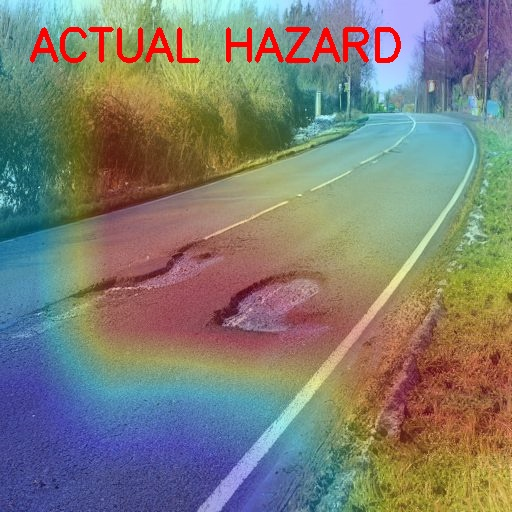

In [46]:
from src.simulate_hazard import RoadHazardSimulator
from src.future_vision import TextureVisionAnalyzer
from google.colab.patches import cv2_imshow
import cv2
import os

# 1. Initialize
sim = RoadHazardSimulator()
vision = TextureVisionAnalyzer()

# 2. Set your input filename (MAKE SURE THIS MATCHES YOUR UPLOADED FILE)
input_file = "pothole-issue-uk.jpg" # Change this if your uploaded file has a different name

if not os.path.exists(input_file):
    print(f"❌ ERROR: I can't find '{input_file}' in your folder. Please upload it first!")
else:
    # 3. Simulate the hazard
    # This creates 'simulated_road.jpg'
    sim_path = sim.simulate(input_file, hazard_type="pothole", output_path="simulated_road.jpg")

    # 4. Analyze with the 'Glow' Heatmap
    # This creates 'final_glow_analysis.jpg'
    vision.visualize("simulated_road.jpg", output_path="final_glow_analysis.jpg")

    # 5. Show the result
    final_img = cv2.imread("final_glow_analysis.jpg")

    if final_img is not None:
        print("🚀 SUCCESS! Showing the predicted hazard outline:")
        cv2_imshow(final_img)
    else:
        print("❌ Something went wrong during the save process.")